In [1]:

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
import pingouin as pg
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
hse_dict = {}
basedir = '/home/mplitt/YMazeReplayPkls_F_dff/'
for cond_key, mice in zip(('ctrl', 'cre'),(ctrl_mice, ko_mice)):
    hse_dict[cond_key] = {}
    for day in range(6):
        hse_dict[cond_key][day] = {}
        for mouse in mice:
            filename = basedir + f'{mouse}_day{day}.pkl'
            hse_dict[cond_key][day][mouse]=filename

In [3]:
def predict_future_tt_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    for react_day in range(5):

        corr_dict[react_day] = {}
        # sess = u.load_single_day(mouse, react_day)

        for tt_corr_day in range(react_day+1,6):
        
            corr_dict[react_day][tt_corr_day] ={}
            
            days = [react_day, tt_corr_day]
            
            if react_day == tt_corr_day:
                
                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                    hse_tt_corr = hse_react
                    hse_tt_corr = u.load_single_day(mouse, tt_corr_day, trial_mat_keys=['F_dff_nostop',], verbose=False)
                
                    
                common_roi_mapping = np.array([np.arange(hse_react.spks.shape[0]) for _ in range(2)])
                
            else:
                common_roi_mapping = u.common_rois_adjust(mouse, days)
                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                    sess = u.load_single_day(mouse, react_day, trial_mat_keys=['F_dff_nostop'], timeseries_keys=['F_dff_nostop'], verbose=False)
               
                    
                hse_tt_corr = u.load_single_day(mouse, tt_corr_day, trial_mat_keys=['F_dff_nostop',], timeseries_keys=['F_dff_nostop'],verbose=False)
                
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                   
                # reactivation mask
                if key == 'fam':
                    trial_mask = hse_tt_corr.trial_info["LR"]!=hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr!=hse_react.novel_arm
                    react_trial_mask = hse_react.trial_info["LR"]!= hse_react.novel_arm
                else:
                    trial_mask = hse_tt_corr.trial_info["LR"]==hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr==hse_react.novel_arm
                    react_trial_mask = hse_react.trial_info["LR"]==hse_react.novel_arm
                

                ts_mask = lr_mask * (hse_react.post_reward_bool>0) * (hse_react.block_number==5)
              
                # ts_mask = (hse_react.post_reward_bool>0) * (hse_react.block_number==5)
               
                if ts_mask.sum()<30:
                    corr_dict[react_day][tt_corr_day][key]['tt_corr']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['hse_corr']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['across_day_corr'] =[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['cell_argmax'] = [np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['react_cell_argmax'] = [np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['react_corr'] = [np.nan,]
                    continue
               

                hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
                                        hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask], axis=-1)    

                # trial_mat = hse_tt_corr.trial_mat[trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                trial_mat = hse_tt_corr.trial_matrices['F_dff_nostop'][trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                cell_argmax = np.nanargmax(np.nanmean(trial_mat,axis=0),axis=0)
                trial_mat[np.isnan(trial_mat)]=0
                corr_mat = np.zeros([trial_mat.shape[0], trial_mat.shape[0], trial_mat.shape[-1]])

               
                for cell in range(corr_mat.shape[-1]):
                    _mat = np.corrcoef(trial_mat[:,:,cell])
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    corr_mat[:, :,cell] = _mat

                react_trial_mat = sess.trial_matrices['F_dff_nostop'][react_trial_mask,:,:][:,:,common_roi_mapping[0,:]]
                react_trial_mat[np.isnan(react_trial_mat)]=0
                react_corr_mat = np.zeros((react_trial_mat.shape[0], react_trial_mat.shape[0], react_trial_mat.shape[-1]))
                for cell in range(react_corr_mat.shape[-1]):
                    _mat = np.corrcoef(react_trial_mat[:,:,cell])
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    react_corr_mat[:, :,cell] = _mat

                corr_dict[react_day][tt_corr_day][key]['tt_corr']=np.array([np.nanmean(np.nanmean(corr_mat,axis=0),axis=0)]).flatten()
                corr_dict[react_day][tt_corr_day][key]['react_corr']=np.array([np.nanmean(np.nanmean(react_corr_mat, axis=0), axis=0)]).flatten()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([hse_r]).flatten()
                corr_dict[react_day][tt_corr_day][key]['cell_argmax'] = np.array([cell_argmax]).flatten()


                react_trial_mat = sess.trial_matrices['F_dff_nostop'][react_trial_mask,:,:][:,:,common_roi_mapping[0,:]]
                react_trial_mat_mean = np.nanmean(react_trial_mat,axis=0)
                corr_dict[react_day][tt_corr_day][key]['react_cell_argmax'] = np.nanargmax(react_trial_mat_mean,axis=0)

                # trial_mat_mean = np.nanmean(hse_tt_corr.trial_mat[trial_mask,:,:][:,:,common_roi_mapping[1,:]], axis=0)
                trial_mat_mean = np.nanmean(hse_tt_corr.trial_matrices['F_dff_nostop'][trial_mask,:,:][:,:,common_roi_mapping[1,:]], axis=0)
                
                react_trial_mat_mean[np.isnan(react_trial_mat_mean)]=0
                trial_mat_mean[np.isnan(trial_mat_mean)]=0
                across_day_corr = np.zeros([trial_mat_mean.shape[-1],])
                for cell in range(trial_mat_mean.shape[-1]):
                    _r,_ = sp.stats.pearsonr(react_trial_mat_mean[:,cell], trial_mat_mean[:,cell])
                    across_day_corr[cell] = _r

                corr_dict[react_day][tt_corr_day][key]['across_day_corr'] = np.array(across_day_corr).flatten()


                
    return corr_dict


In [4]:
rows = []
for cond, mice in zip(('ctrl','cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        corr_dict = predict_future_tt_stability(mouse)
        for i in range(5):
            for j in range(i+1,6):
                for ttype in ('fam', 'nov'):
                
                    hse_corr = corr_dict[i][j][ttype]['hse_corr']
                    tt_corr =  corr_dict[i][j][ttype]['tt_corr']
                    across_day_corr = corr_dict[i][j][ttype]['across_day_corr']
                    cell_argmax = corr_dict[i][j][ttype]['cell_argmax']
                    react_argmax = corr_dict[i][j][ttype]['react_cell_argmax']
                    react_corr = corr_dict[i][j][ttype]['react_corr']
                    # print(hse_corr.shape)
                    
                    nanmask = np.isnan(np.array(hse_corr).flatten()*np.array(tt_corr).flatten())
                    nanmask = np.array([nanmask,]).ravel()
                    if nanmask.shape[0]==1:
                        continue
                    # print(hse_corr)
                    hse_corr[nanmask] = 0
                

                    for hse, tt, ad,amax,r_amax, r_corr in zip(hse_corr, tt_corr, across_day_corr, cell_argmax, react_argmax, react_corr):
                        rows.append({'condition':cond,
                                    'mouse':mouse,
                                    'ttype': ttype,
                                    'hse_day':i,
                                    'tt_day':j,
                                    'hse_corr':hse,
                                    'tt_corr':tt,
                                    'across_day_corr': ad,
                                    'cell_argmax': amax,
                                    'react_cell_argmax': r_amax,
                                    'react_corr': r_corr})
df = pd.DataFrame(rows)


4467331.1
4467331.1


/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined

4467331.2
4467331.2


/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


[3, 4]
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel


...

/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined

Cre7
Cre7


/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined

Cre9
Cre9


/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  hse_r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_282621/2806057502.py:66: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined

In [5]:
df.to_pickle('/home/mplitt/shuffle_pkls/hse_corr_results_dff.pkl')

In [4]:
with open('/home/mplitt/shuffle_pkls/hse_corr_results_dff.pkl', 'rb') as file:
    df = pickle.load(file)

In [5]:
cre_mask = df['condition']=='cre'
nonzero_mask = df['hse_corr']>0

df['hse_zero_mask'] = 1.*(df['hse_corr']==0)


df['hse_corr_z'] = np.arctanh(df['hse_corr'])
df['tt_corr_z'] = np.arctanh(df['tt_corr'])
df['across_day_corr_z'] = np.arctanh(df['across_day_corr'])
df['within_cell_corr_diff'] = df['tt_corr'] - df['react_corr']
df_pos = df.loc[nonzero_mask].groupby(['condition','hse_day', 'tt_day', 'ttype', 'mouse']).mean().reset_index()
df_neg = df.loc[~nonzero_mask].groupby(['condition','hse_day', 'tt_day', 'ttype', 'mouse']).mean().reset_index()
df_pos['positive']= True
df_neg['positive']= False
df_pos['tt_corr_diff'] = df_pos['tt_corr']-df_neg['tt_corr']



In [6]:
df['tt_corr_diff'] = np.nan
for mouse in df['mouse'].unique():
    for hse_day in df['hse_day'].unique():
        for tt_day in df['tt_day'].unique():
            mask = (df['mouse']==mouse) * (df['hse_day']==hse_day) * (df['tt_day']==tt_day)
            pos_sub_df = df.loc[mask*nonzero_mask]
            neg_sub_df = df.loc[~nonzero_mask*mask]
            

            df.loc[mask*nonzero_mask,'tt_corr_diff'] = pos_sub_df['tt_corr'] - np.nanmean(neg_sub_df['tt_corr'])
            df.loc[~nonzero_mask*mask, 'tt_corr_diff'] = neg_sub_df['tt_corr'] - np.nanmean(neg_sub_df['tt_corr'])

/tmp/ipykernel_287767/4233580211.py:10: RuntimeWarning: Mean of empty slice
  df.loc[mask*nonzero_mask,'tt_corr_diff'] = pos_sub_df['tt_corr'] - np.nanmean(neg_sub_df['tt_corr'])
/tmp/ipykernel_287767/4233580211.py:11: RuntimeWarning: Mean of empty slice
  df.loc[~nonzero_mask*mask, 'tt_corr_diff'] = neg_sub_df['tt_corr'] - np.nanmean(neg_sub_df['tt_corr'])
/tmp/ipykernel_287767/4233580211.py:10: RuntimeWarning: Mean of empty slice
  df.loc[mask*nonzero_mask,'tt_corr_diff'] = pos_sub_df['tt_corr'] - np.nanmean(neg_sub_df['tt_corr'])
/tmp/ipykernel_287767/4233580211.py:11: RuntimeWarning: Mean of empty slice
  df.loc[~nonzero_mask*mask, 'tt_corr_diff'] = neg_sub_df['tt_corr'] - np.nanmean(neg_sub_df['tt_corr'])
/tmp/ipykernel_287767/4233580211.py:10: RuntimeWarning: Mean of empty slice
  df.loc[mask*nonzero_mask,'tt_corr_diff'] = pos_sub_df['tt_corr'] - np.nanmean(neg_sub_df['tt_corr'])
/tmp/ipykernel_287767/4233580211.py:11: RuntimeWarning: Mean of empty slice
  df.loc[~nonzero_mask*ma

In [7]:
df.loc[df['condition']=='ctrl']

,condition,mouse,ttype,hse_day,tt_day,hse_corr,tt_corr,across_day_corr,cell_argmax,react_cell_argmax,react_corr,hse_zero_mask,hse_corr_z,tt_corr_z,across_day_corr_z,within_cell_corr_diff,tt_corr_diff
0,ctrl,4467331.1,fam,0,1,0.230127,0.518289,0.936597,16,16,0.208601,0.0,0.234323,0.573998,1.709592,0.309688,0.209773
1,ctrl,4467331.1,fam,0,1,0.113286,0.470235,0.970955,27,27,0.204430,0.0,0.113774,0.510372,2.108705,0.265805,0.161719
2,ctrl,4467331.1,fam,0,1,0.000000,0.858873,0.993875,23,23,0.728486,1.0,0.000000,1.289032,2.892692,0.130386,0.550357
3,ctrl,4467331.1,fam,0,1,0.000000,0.470414,0.926142,24,24,0.580263,1.0,0.000000,0.510602,1.630563,-0.109849,0.161898
4,ctrl,4467331.1,fam,0,1,0.055509,0.612274,0.993313,27,27,0.469320,0.0,0.055566,0.712552,2.848682,0.142954,0.303758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160419,ctrl,mCherry9,nov,4,5,0.000000,0.082677,0.944336,26,26,0.696718,1.0,0.000000,0.082866,1.776670,-0.614041,-0.136410
160420,ctrl,mCherry9,nov,4,5,0.000000,0.044914,0.774824,21,22,0.418904,1.0,0.000000,0.044944,1.032287,-0.373990,-0.174173
160421,ctrl,mCherry9,nov,4,5,0.000000,0.228026,0.581015,0,19,0.064972,1.0,0.000000,0.232107,0.663993,0.163054,0.008939
160422,ctrl,mCherry9,nov,4,5,0.000000,0.224464,0.896697,1,3,0.154354,1.0,0.000000,0.228352,1.455100,0.070110,0.005377


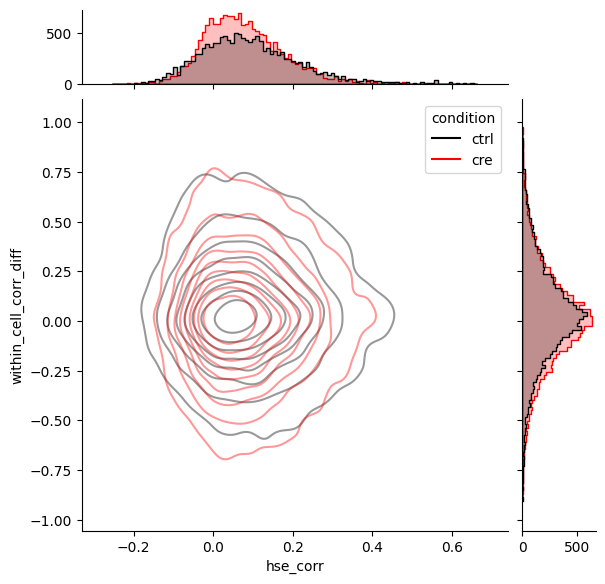

In [8]:
g = sns.JointGrid(data=df.loc[(df['hse_zero_mask']!=1)*(df['ttype']=='nov')],
                          x='hse_corr',
                          hue='condition',
                           y='within_cell_corr_diff',
                          hue_order=['ctrl','cre'],
                          palette=['black', 'red'],
                          marginal_ticks=True)
g.plot_joint(sns.kdeplot, alpha=.4)
g.plot_marginals(sns.histplot, element='step')
# g.plot_marginals(sns.histplot, cumulative=True, element='step', fill=False, stat='proportion')

<Axes: xlabel='hse_day', ylabel='hse_zero_mask'>

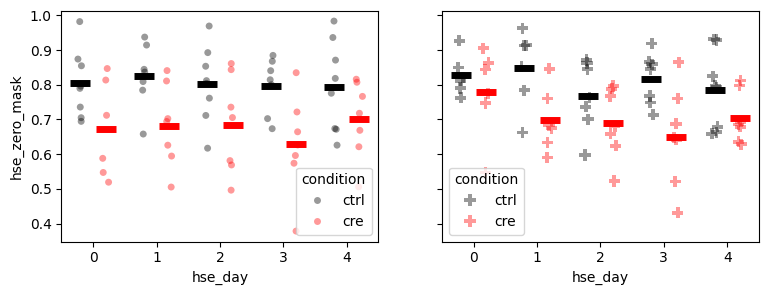

In [9]:
# proportion that are inactive
tmp_df= df.groupby(['condition', 'mouse', 'hse_day', 'ttype']).mean().reset_index()


fig, ax = plt.subplots(1,2,figsize=[9,3], sharex=True, sharey=True)
_ = sns.stripplot(data = tmp_df.loc[tmp_df['ttype']=='fam'],
                  x='hse_day',
                  y='hse_zero_mask',
                  hue = 'condition',
                  hue_order= ['ctrl','cre'],
                  palette=['black','red'],
                  ax=ax[0], dodge=True, alpha=.4, s=5)

tmp_df_mu = tmp_df.groupby(['condition', 'hse_day', 'ttype'])['hse_zero_mask'].mean().reset_index()
sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='fam'],
            x='hse_day',
            y='hse_zero_mask',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'cre'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )


_ = sns.stripplot(data = tmp_df.loc[tmp_df['ttype']=='nov'],
                  x='hse_day',
                  y='hse_zero_mask',
                  hue = 'condition',
                  hue_order= ['ctrl','cre'],
                  palette=['black','red'],
                  ax=ax[1], dodge=True, alpha=.4, s=8, marker='P')

sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='nov'],
            x='hse_day',
            y='hse_zero_mask',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'cre'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )

In [10]:
tmp_df['rank_zero_mask'] = tmp_df['hse_zero_mask'].rank()
aov = pg.mixed_anova(tmp_df, dv='rank_zero_mask',
                     subject='mouse', within='hse_day',
                     between='condition')
print(aov)

        Source            SS  DF1  DF2            MS         F     p-unc  \
0    condition  27360.582424    1    9  27360.582424  9.194662  0.014194   
1      hse_day   2668.245455    4   36    667.061364  1.127447  0.358960   
2  Interaction   3140.814545    4   36    785.203636  1.327127  0.278597   

        np2       eps  
0  0.505349       NaN  
1  0.111326  0.709413  
2  0.128509       NaN  


<Axes: xlabel='hse_day', ylabel='hse_corr'>

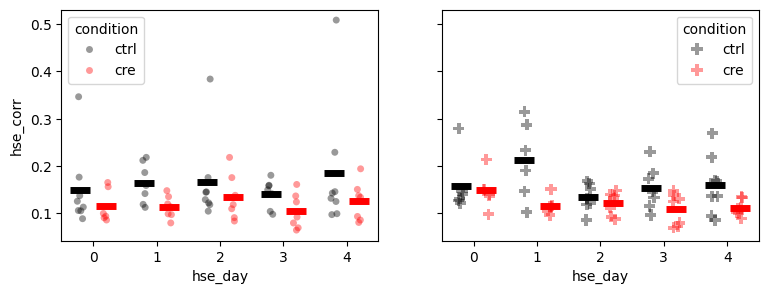

In [11]:
fig, ax = plt.subplots(1,2,figsize=[9,3], sharex=True, sharey=True)
tmp_df= df[nonzero_mask].groupby(['condition', 'mouse', 'hse_day', 'ttype']).mean().reset_index()
_ = sns.stripplot(data = tmp_df.loc[tmp_df['ttype']=='fam'],
                  x='hse_day',
                  y='hse_corr',
                  hue = 'condition',
                  hue_order= ['ctrl','cre'],
                  palette=['black','red'],
                  ax=ax[0], dodge=True, alpha=.4, s=5)

tmp_df_mu = tmp_df.groupby(['condition', 'hse_day', 'ttype'])['hse_corr'].mean().reset_index()
sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='fam'],
            x='hse_day',
            y='hse_corr',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'cre'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )


_ = sns.stripplot(data = tmp_df.loc[tmp_df['ttype']=='nov'],
                  x='hse_day',
                  y='hse_corr',
                  hue = 'condition',
                  hue_order= ['ctrl','cre'],
                  palette=['black','red'],
                  ax=ax[1], dodge=True, alpha=.4, s=8, marker='P')

sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='nov'],
            x='hse_day',
            y='hse_corr',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'cre'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )

In [12]:
tmp_df['rank_hse_corr'] = tmp_df['hse_corr'].rank()
aov = pg.mixed_anova(tmp_df, dv='rank_hse_corr',
                     subject='mouse', within='hse_day',
                     between='condition')
print(aov)

        Source            SS  DF1  DF2            MS         F     p-unc  \
0    condition  24314.882424    1    9  24314.882424  9.676099  0.012506   
1      hse_day   1006.845455    4   36    251.711364  0.385430  0.817599   
2  Interaction   4839.147879    4   36   1209.786970  1.852470  0.140189   

        np2       eps  
0  0.518101       NaN  
1  0.041067  0.678382  
2  0.170696       NaN  


        Source          SS  DF1  DF2          MS          F     p-unc  \
0    condition  853.841270    1   14  853.841270  10.111821  0.006682   
1        ttype  180.500000    1   14  180.500000   4.981258  0.042480   
2  Interaction    4.198413    1   14    4.198413   0.115864  0.738618   

        np2  eps  
0  0.419372  NaN  
1  0.262430  1.0  
2  0.008208  NaN  


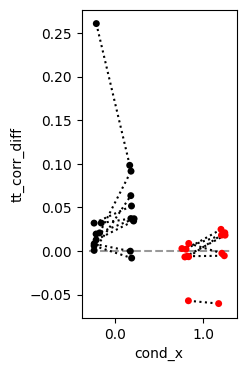

In [13]:
tmp_df = df_pos.groupby(['condition', 'mouse', 'ttype']).mean().reset_index()
tmp_df['cond_x'] = 1.*(tmp_df['condition']=='cre')

fig, ax = plt.subplots(figsize=[2,4])
sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='ctrl'],
              x='cond_x',
              # y='within_cell_corr_diff',
              y='tt_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['black', 'black'],
              legend=False,
              ax=ax)

sns.stripplot(data=tmp_df.loc[tmp_df['condition']=='cre'],
              x='cond_x',
              y='tt_corr_diff',
              # y='within_cell_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['red', 'red'],
              legend=False,
              ax=ax)
for d in [0,2]:
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
ax.hlines(0,-.3, 1.3, linestyle='--', color='black', alpha=.4)


tmp_df['rank_tt_corr_diff'] = tmp_df['tt_corr_diff'].rank()
aov = pg.mixed_anova(tmp_df, dv='rank_tt_corr_diff',
                     subject='mouse', within='ttype',
                     between='condition')
print(aov)

In [14]:
stat, p = sp.stats.wilcoxon(tmp_df.loc[(tmp_df['condition']=='ctrl')*(tmp_df['ttype']=='fam'), 'tt_corr_diff'])
print(stat,p)
stat, p = sp.stats.wilcoxon(tmp_df.loc[(tmp_df['condition']=='ctrl')*(tmp_df['ttype']=='nov'), 'tt_corr_diff'])
print(stat,p)

stat, p = sp.stats.wilcoxon(tmp_df.loc[(tmp_df['condition']=='cre')*(tmp_df['ttype']=='fam'), 'tt_corr_diff'])
print(stat,p)
stat, p = sp.stats.wilcoxon(tmp_df.loc[(tmp_df['condition']=='cre')*(tmp_df['ttype']=='nov'), 'tt_corr_diff'])
print(stat,p)



stat, p = sp.stats.mannwhitneyu(tmp_df.loc[(tmp_df['condition']=='ctrl'), 'tt_corr_diff'],
                           tmp_df.loc[(tmp_df['condition']=='cre'), 'tt_corr_diff'])
print(stat,p)

stat, p = sp.stats.mannwhitneyu(tmp_df.loc[(tmp_df['condition']=='ctrl')*(tmp_df['ttype']=='nov'), 'tt_corr_diff'],
                           tmp_df.loc[(tmp_df['condition']=='cre')*(tmp_df['ttype']=='nov'), 'tt_corr_diff'])
print(stat,p)

stat, p = sp.stats.mannwhitneyu(tmp_df.loc[(tmp_df['condition']=='ctrl')*(tmp_df['ttype']=='fam'), 'tt_corr_diff'],
                           tmp_df.loc[(tmp_df['condition']=='cre')*(tmp_df['ttype']=='fam'), 'tt_corr_diff'])
print(stat,p)

0.0 0.00390625
3.0 0.01953125
9.0 0.46875
10.0 0.578125
208.0 0.0019619733796795874
53.0 0.022902097902097907
58.0 0.003321678321678322


In [15]:
ctrl_corr_mats = {'nov': {'zero': np.nan*np.zeros((6,6)),
                        'nonzero': np.nan*np.zeros((6,6)),
                        'diff': np.nan*np.zeros((6,6))},
                  'fam' : {'zero': np.nan*np.zeros((6,6)),
                        'nonzero': np.nan*np.zeros((6,6)),
                         'diff': np.nan*np.zeros((6,6))}}

ko_corr_mats = {'nov': {'zero': np.nan*np.zeros((6,6)),
                        'nonzero': np.nan*np.zeros((6,6)),
                        'diff': np.nan*np.zeros((6,6))},
                  'fam' : {'zero': np.nan*np.zeros((6,6)),
                        'nonzero': np.nan*np.zeros((6,6)),
                         'diff': np.nan*np.zeros((6,6))}}


tmp_df = df.loc[nonzero_mask].groupby(['condition', 'mouse', 'ttype', 'hse_day', 'tt_day']).mean().reset_index()
for hse_day in range(5):
    for tt_day in range(hse_day+1, 6):
        ##
        mask = (tmp_df['hse_day']==hse_day) * (tmp_df['tt_day']==tt_day) * (tmp_df['condition']=='ctrl')

        fam_mask = mask*(tmp_df['ttype']=='fam')
        ctrl_corr_mats['fam']['nonzero'][hse_day,tt_day] = tmp_df.loc[fam_mask,'tt_corr'].mean()
        ctrl_corr_mats['fam']['diff'][hse_day, tt_day] = tmp_df.loc[fam_mask, 'tt_corr_diff'].mean()

        nov_mask = mask*(tmp_df['ttype']=='nov')

        ctrl_corr_mats['nov']['nonzero'][hse_day,tt_day] = tmp_df.loc[nov_mask,'tt_corr'].mean()
        ctrl_corr_mats['nov']['diff'][hse_day, tt_day] = tmp_df.loc[nov_mask, 'tt_corr_diff'].mean()

        ##
        mask = (tmp_df['hse_day']==hse_day) * (tmp_df['tt_day']==tt_day) * (tmp_df['condition']=='cre')

        fam_mask = mask*(tmp_df['ttype']=='fam')
        ko_corr_mats['fam']['nonzero'][hse_day,tt_day] = tmp_df.loc[fam_mask,'tt_corr'].mean()
        ko_corr_mats['fam']['diff'][hse_day, tt_day] = tmp_df.loc[fam_mask, 'tt_corr_diff'].mean()

        nov_mask = mask*(tmp_df['ttype']=='nov')

        ko_corr_mats['nov']['nonzero'][hse_day,tt_day] = tmp_df.loc[nov_mask,'tt_corr'].mean()
        ko_corr_mats['nov']['diff'][hse_day, tt_day] = tmp_df.loc[nov_mask, 'tt_corr_diff'].mean()


tmp_df = df.loc[~nonzero_mask].groupby(['condition', 'mouse', 'ttype', 'hse_day', 'tt_day']).mean().reset_index()
for hse_day in range(5):
    for tt_day in range(hse_day+1, 6):
        ##
        mask = (tmp_df['hse_day']==hse_day) * (tmp_df['tt_day']==tt_day) * (tmp_df['condition']=='ctrl')

        fam_mask = mask*(tmp_df['ttype']=='fam')
        ctrl_corr_mats['fam']['zero'][hse_day,tt_day] = tmp_df.loc[fam_mask,'tt_corr'].mean()
        

        nov_mask = mask*(tmp_df['ttype']=='nov')
        ctrl_corr_mats['nov']['zero'][hse_day,tt_day] = tmp_df.loc[nov_mask,'tt_corr'].mean()
        
        ##
        mask = (tmp_df['hse_day']==hse_day) * (tmp_df['tt_day']==tt_day) * (tmp_df['condition']=='cre')

        fam_mask = mask*(tmp_df['ttype']=='fam')
        ko_corr_mats['fam']['zero'][hse_day,tt_day] = tmp_df.loc[fam_mask,'tt_corr'].mean()
       
        nov_mask = mask*(tmp_df['ttype']=='nov')
        ko_corr_mats['nov']['zero'][hse_day,tt_day] = tmp_df.loc[nov_mask,'tt_corr'].mean()
       


Text(0.5, 0.98, 'Cre mice')

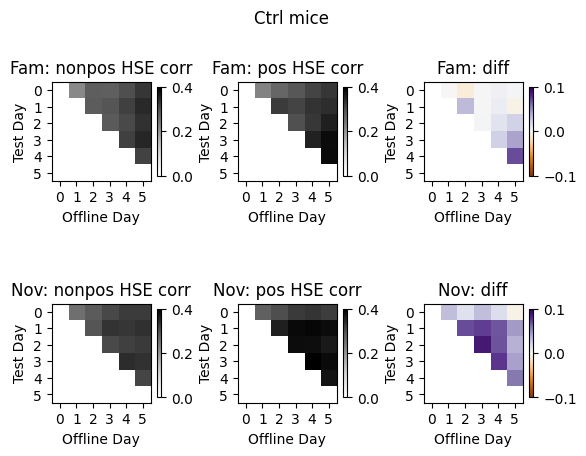

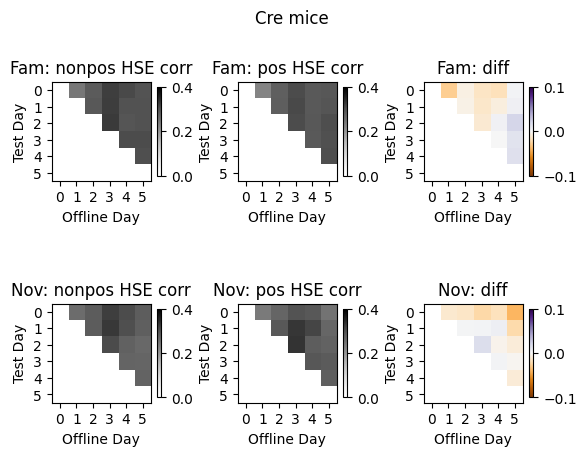

In [16]:
def plot_corr_mats(corr_mat_dict, 
                   cmaps={'corr': 'Greys', 'corr_diff': 'PuOr'}, 
                   clims = {'corr': {'vmin': 0, 'vmax': .4}, 'corr_diff':{'vmin':-.1, 'vmax':.1}},
                   cbar_shrink = .6):
    fig, ax = plt.subplots(2,3)
    fig.subplots_adjust(hspace=.5, wspace=.5)

    h = ax[0,0].imshow(corr_mat_dict['fam']['zero'], cmap=cmaps['corr'], vmin=clims['corr']['vmin'], vmax=clims['corr']['vmax'])
    ax[0,0].set_title('Fam: nonpos HSE corr')
    fig.colorbar(h, shrink=cbar_shrink)

    h=ax[0,1].imshow(corr_mat_dict['fam']['nonzero'], cmap=cmaps['corr'], vmin=clims['corr']['vmin'], vmax=clims['corr']['vmax'])
    ax[0,1].set_title('Fam: pos HSE corr')
    fig.colorbar(h, shrink=cbar_shrink)

    h=ax[0,2].imshow(corr_mat_dict['fam']['diff'], cmap=cmaps['corr_diff'], vmin=clims['corr_diff']['vmin'], vmax=clims['corr_diff']['vmax'])
    ax[0,2].set_title('Fam: diff')
    fig.colorbar(h, shrink=cbar_shrink)


    h=ax[1,0].imshow(corr_mat_dict['nov']['zero'], cmap=cmaps['corr'], vmin=clims['corr']['vmin'], vmax=clims['corr']['vmax'])
    ax[1,0].set_title('Nov: nonpos HSE corr')
    fig.colorbar(h, shrink=cbar_shrink)

    h=ax[1,1].imshow(corr_mat_dict['nov']['nonzero'], cmap=cmaps['corr'], vmin=clims['corr']['vmin'], vmax=clims['corr']['vmax'])
    ax[1,1].set_title('Nov: pos HSE corr')
    fig.colorbar(h, shrink=cbar_shrink)

    h=ax[1,2].imshow(corr_mat_dict['nov']['diff'], cmap=cmaps['corr_diff'], vmin=clims['corr_diff']['vmin'], vmax=clims['corr_diff']['vmax'])
    ax[1,2].set_title('Nov: diff')
    fig.colorbar(h, shrink=cbar_shrink)

    for a in ax.flatten():
        a.set_xticks(np.arange(6))
        a.set_yticks(np.arange(6))
        a.set_xlabel('Offline Day')
        a.set_ylabel('Test Day')
    return fig, ax

fig, ax = plot_corr_mats(ctrl_corr_mats)
fig.suptitle('Ctrl mice')

fig, ax = plot_corr_mats(ko_corr_mats)
fig.suptitle('Cre mice')


In [17]:
sess = u.load_single_day(ctrl_mice[0],0)
rz_early = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_early['tfront'])[0], np.argwhere(sess.rzone_early['tback']<=sess.trial_matrices['bin_edges'][1:])[0] )
rz_late = (np.argwhere(sess.trial_matrices['bin_edges'][:-1]>=sess.rzone_late['tfront'])[0], 29 )

df['cell_argmax_rz_centered']=np.nan
df['react_cell_argmax_rz_centered']=np.nan
for cond, mice in zip(('ctrl', 'cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
                        
        if cond=='ctrl':
            novel_arm = stx.ymaze_sess_deets.CTRL_sessions[mouse][day]['novel_arm']
        else:
            novel_arm = stx.ymaze_sess_deets.KO_sessions[mouse][day]['novel_arm']

        if novel_arm == 1: 
            rz_nov = rz_late
            rz_fam = rz_early
        else: 
            rz_nov = rz_early
            rz_fam = rz_late

        for ttype in ('nov', 'fam'):
            if ttype == 'nov':
                rz = rz_nov
            else:
                rz = rz_fam
            mask = (df['mouse']==mouse) * (df['ttype']==ttype)
            df.loc[mask, 'cell_argmax_rz_centered'] = df['cell_argmax'] - rz[0]
            df.loc[mask, 'react_cell_argmax_rz_centered'] = df['react_cell_argmax'] - rz[0]


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


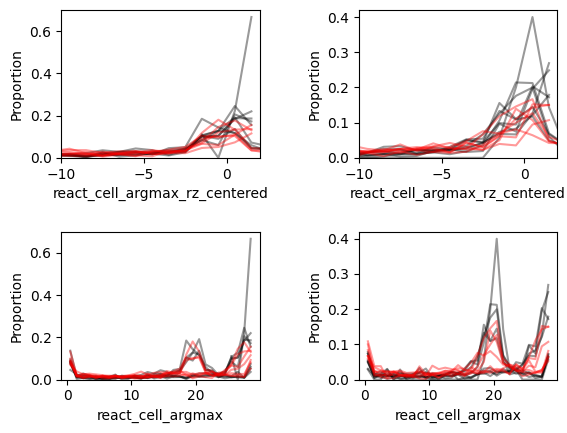

In [20]:
fig, ax = plt.subplots(2,2)
for mouse in ctrl_mice:
    sns.histplot(data=df.loc[nonzero_mask*(df['ttype']=='fam')* (df['mouse']==mouse)],
             x='react_cell_argmax_rz_centered',
             color='black',
             element='poly',
             stat='proportion', fill=False, alpha=.4, binwidth=1, ax=ax[0,0])
    
    sns.histplot(data=df.loc[nonzero_mask*(df['ttype']=='nov')* (df['mouse']==mouse)],
             x='react_cell_argmax_rz_centered',
             color='black',
             element='poly',
             stat='proportion', fill=False, alpha=.4, binwidth=1, ax=ax[0,1])
    
    sns.histplot(data=df.loc[nonzero_mask*(df['ttype']=='fam')* (df['mouse']==mouse)],
             x='react_cell_argmax',
             color='black',
             element='poly',
             stat='proportion', fill=False, alpha=.4, binwidth=1, ax=ax[1,0])
    
    sns.histplot(data=df.loc[nonzero_mask*(df['ttype']=='nov')* (df['mouse']==mouse)],
             x='react_cell_argmax',
             color='black',
             element='poly',
             stat='proportion', fill=False, alpha=.4, binwidth=1, ax=ax[1,1])

for mouse in ko_mice:
    sns.histplot(data=df.loc[nonzero_mask*(df['ttype']=='fam')* (df['mouse']==mouse)],
             x='react_cell_argmax_rz_centered',
             color='red',
             element='poly',
             stat='proportion', fill=False, alpha=.4, binwidth=1, ax=ax[0,0])
    
    sns.histplot(data=df.loc[nonzero_mask*(df['ttype']=='nov')* (df['mouse']==mouse)],
             x='react_cell_argmax_rz_centered',
             color='red',
             element='poly',
             stat='proportion', fill=False, alpha=.4, binwidth=1, ax=ax[0,1])
    
    sns.histplot(data=df.loc[nonzero_mask*(df['ttype']=='fam')* (df['mouse']==mouse)],
             x='react_cell_argmax',
             color='red',
             element='poly',
             stat='proportion', fill=False, alpha=.4, binwidth=1, ax=ax[1,0])
    
    sns.histplot(data=df.loc[nonzero_mask*(df['ttype']=='nov')* (df['mouse']==mouse)],
             x='react_cell_argmax',
             color='red',
             element='poly',
             stat='proportion', fill=False, alpha=.4, binwidth=1, ax=ax[1,1])


ax[0, 0].set_xlim([-10,2])
ax[0, 1].set_xlim([-10,2])
fig.subplots_adjust(wspace=.5, hspace=.5)


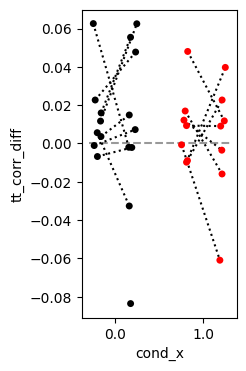

In [21]:
tmp_df = df.copy()
mask = (tmp_df['react_cell_argmax_rz_centered']<=-5)+(tmp_df['react_cell_argmax_rz_centered']>3)
# mask = (tmp_df['react_cell_argmax_rz_centered']>=-5)*(tmp_df['react_cell_argmax_rz_centered']<3)

tmp_df_pos = tmp_df.loc[mask*nonzero_mask].groupby(['condition', 'mouse', 'ttype','hse_day', 'tt_day']).mean().reset_index()
tmp_df_neg = tmp_df.loc[mask*(~nonzero_mask)].groupby(['condition', 'mouse', 'ttype', 'hse_day', 'tt_day']).mean().reset_index()
# tmp_df_pos['tt_corr_diff'] = tmp_df_pos['tt_corr_z']-tmp_df_neg['tt_corr_z']

tmp_df_pos= tmp_df_pos.groupby(['condition', 'mouse', 'ttype']).mean().reset_index()
tmp_df_pos['cond_x'] = 1.*(tmp_df_pos['condition']=='cre')



fig, ax = plt.subplots(figsize=[2,4])
sns.stripplot(data=tmp_df_pos.loc[tmp_df_pos['condition']=='ctrl'],
              x='cond_x',
              y='tt_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['black', 'black'],
              legend=False,
              ax=ax)

sns.stripplot(data=tmp_df_pos.loc[tmp_df_pos['condition']=='cre'],
              x='cond_x',
              y='tt_corr_diff',
              hue='ttype',
              dodge=True,
              hue_order=['fam', 'nov'],
              palette=['red', 'red'],
              legend=False,
              ax=ax)
for d in [0,2]:
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
ax.hlines(0,-.3, 1.3, linestyle='--', color='black', alpha=.4)


In [47]:
# for each mouse
rows = []
for cond, mice in zip(('ctrl', 'cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        for day in range(5):                      
            
            if cond=='ctrl':
                novel_arm = stx.ymaze_sess_deets.CTRL_sessions[mouse][0]['novel_arm']
            else:
                novel_arm = stx.ymaze_sess_deets.KO_sessions[mouse][0]['novel_arm']

            if novel_arm == 1: 
                rz_nov = rz_late
                rz_fam = rz_early
            else: 
                rz_nov = rz_early
                rz_fam = rz_late

            for ttype in ('nov', 'fam'):
                if ttype == 'nov':
                    rz = rz_nov
                else:
                    rz = rz_fam


                mask = (df['mouse']==mouse) * (df['ttype']==ttype) * (df['hse_day']==day)
                # positively correlated
                tmp_df = df.loc[nonzero_mask*mask]
                prop_posreward = (1.*((tmp_df['react_cell_argmax_rz_centered']<=0) * (tmp_df['react_cell_argmax_rz_centered']>=-5))).mean()

                # rows.append({'condition': cond,
                #              'mouse': mouse, 
                #              'hse_day': day,
                #              'ttype': ttype,
                #             #  'positive': True,
                #              'prop_reward': prop_reward})

                tmp_df = df.loc[~nonzero_mask*mask]
                prop_negreward = (1.*((tmp_df['cell_argmax_rz_centered']<=0) * (tmp_df['cell_argmax_rz_centered']>=-5))).mean()

                rows.append({'condition': cond,
                             'mouse': mouse, 
                             'hse_day': day,
                             'ttype': ttype,
                             'prop_reward': prop_posreward,
                             'prop_negreward': prop_negreward,
                             'prop_reward_diff': prop_posreward-prop_negreward})


reward_frac_df = pd.DataFrame(rows)

<Axes: xlabel='hse_day', ylabel='prop_reward'>

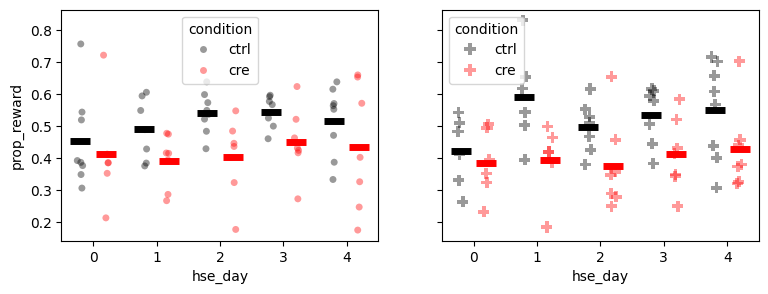

In [48]:
fig, ax = plt.subplots(1,2,figsize=[9,3], sharex=True, sharey=True)
_ = sns.stripplot(data = reward_frac_df.loc[(reward_frac_df['ttype']=='fam')],
                  x='hse_day',
                  y='prop_reward',
                  hue = 'condition',
                  hue_order= ['ctrl','cre'],
                  palette=['black','red'],
                  ax=ax[0], dodge=True, alpha=.4, s=5)

tmp_df_mu = reward_frac_df.groupby(['condition', 'hse_day', 'ttype'])['prop_reward'].mean().reset_index()
sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='fam'],
            x='hse_day',
            y='prop_reward',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'cre'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )


_ = sns.stripplot(data = reward_frac_df.loc[(reward_frac_df['ttype']=='nov')],
                  x='hse_day',
                  y='prop_reward',
                  hue = 'condition',
                  hue_order= ['ctrl','cre'],
                  palette=['black','red'],
                  ax=ax[1], dodge=True, alpha=.4, s=8, marker='P')

sns.pointplot(data=tmp_df_mu.loc[tmp_df_mu['ttype']=='nov'],
            x='hse_day',
            y='prop_reward',
            errorbar=None,
            hue='condition',
            hue_order = ['ctrl', 'cre'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=1.,
            )




In [51]:
reward_frac_df['rank_prop_reward'] = reward_frac_df['prop_reward'].rank()
aov = pg.mixed_anova(data = reward_frac_df.loc[(reward_frac_df['ttype']=='fam') ], 
                     subject='mouse',
                     within='hse_day',
                     between='condition',
                     dv='rank_prop_reward')
print(aov)

aov = pg.mixed_anova(data = reward_frac_df.loc[(reward_frac_df['ttype']=='nov') ], 
                     subject='mouse',
                     within='hse_day',
                     between='condition',
                     dv='rank_prop_reward')
print(aov)

        Source            SS  DF1  DF2            MS         F     p-unc  \
0    condition  14796.049091    1    9  14796.049091  4.126499  0.072772   
1      hse_day   7090.109091    4   36   1772.527273  2.342721  0.073314   
2  Interaction    504.917576    4   36    126.229394  0.166835  0.953854   

        np2       eps  
0  0.314364       NaN  
1  0.206540  0.563402  
2  0.018200       NaN  
        Source            SS  DF1  DF2            MS         F     p-unc  \
0    condition  32281.336111    1    7  32281.336111  9.348325  0.018388   
1      hse_day   2974.188889    4   28    743.547222  1.232536  0.319672   
2  Interaction   1141.261111    4   28    285.315278  0.472951  0.755150   

   p-GG-corr       np2       eps sphericity   W-spher   p-spher  
0        NaN  0.571822       NaN        NaN       NaN       NaN  
1   0.293633  0.149715  0.634289      False  0.055883  0.034712  
2        NaN  0.063288       NaN        NaN       NaN       NaN  


In [52]:
df_grouped = pd.concat([df_pos, df_neg], axis=0)
df_grouped['tt_day_diff'] = df_grouped['tt_day']-df_grouped['hse_day']

In [53]:
df_grouped.head()

,condition,hse_day,tt_day,ttype,mouse,hse_corr,tt_corr,across_day_corr,cell_argmax,react_cell_argmax,react_corr,hse_zero_mask,hse_corr_z,tt_corr_z,across_day_corr_z,tt_corr_diff,positive,tt_day_diff
0,cre,0,1,fam,4467975.1,0.156915,0.119335,0.594287,18.218182,19.363636,0.098512,0.0,0.160348,0.121201,0.805569,-0.044148,True,1
1,cre,0,1,fam,4467975.2,0.190060,0.190074,0.611543,16.653846,17.923077,0.150118,0.0,0.195252,0.198016,0.994753,-0.060706,True,1
2,cre,0,1,fam,4467975.3,0.092260,0.271034,0.621271,18.786667,18.173333,0.199125,0.0,0.092845,0.299328,0.969915,-0.018807,True,1
3,cre,0,1,fam,4467975.4,0.084377,0.264434,0.397057,16.076923,15.179487,0.157186,0.0,0.084984,0.293983,0.573199,0.004417,True,1
4,cre,0,1,fam,4467975.5,0.100057,0.224171,0.505378,16.143293,15.478659,0.162317,0.0,0.101023,0.239291,0.714513,-0.048913,True,1


Text(0.5, 1.0, 'Cre: Nov')

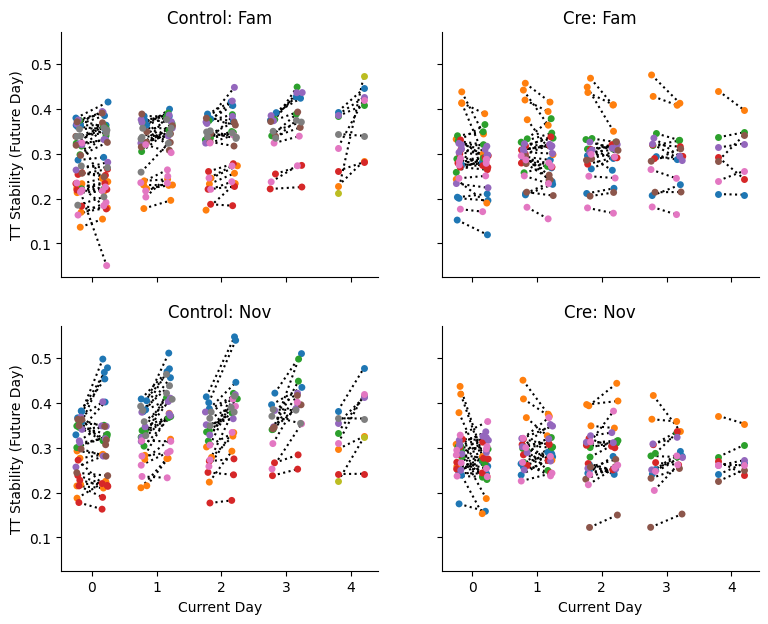

In [54]:
fig, ax = plt.subplots(2,2, figsize=(9,7), sharex=True, sharey=True)

for k, ttype in enumerate(['fam','nov']):
    old_ind = 0
    for i, mouse in enumerate(ctrl_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='ctrl') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
            
        

        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='tt_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,0])
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,0].collections[d].get_offsets(), ax[k,0].collections[d+1].get_offsets()):
                ax[k,0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
        


    old_ind = 0
    for i, mouse in enumerate(ko_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='cre') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='tt_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,1])
        
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,1].collections[d].get_offsets(), ax[k,1].collections[d+1].get_offsets()):
                ax[k,1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
    
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('Current Day')
    a.set_ylabel('TT Stability (Future Day)')
ax[0,0].set_title('Control: Fam')
ax[0,1].set_title('Cre: Fam')
ax[1,0].set_title('Control: Nov')
ax[1,1].set_title('Cre: Nov')


In [55]:
import statsmodels.formula.api as smf
df_tmp = df_grouped.copy()
df_tmp['condition'] = df_tmp['condition'].astype('category')
df_tmp['mouse'] = df_tmp['mouse'].astype('category')
df_tmp['hse_day'] = df_tmp['hse_day'].astype('category')
df_tmp['tt_day'] = df_tmp['tt_day'].astype('category')
df_tmp['ttype'] = df_tmp['ttype'].astype('category')
df_tmp['positive'] = df_tmp['positive'].astype('category')
df_tmp['tt_corr_rank'] = df_tmp['tt_corr'].rank()
df_tmp['across_day_corr_rank'] = df_tmp['across_day_corr'].rank()




In [56]:
_df_tmp = df_tmp.loc[df_tmp['ttype']=='nov']
model = smf.mixedlm("tt_corr_rank ~ positive * condition + hse_day + tt_day", 
                    _df_tmp, groups=_df_tmp["mouse"])

res = model.fit()
res.summary()



<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
=================================================================================
Model:                     MixedLM        Dependent Variable:        tt_corr_rank
No. Observations:          386            Method:                    REML        
No. Groups:                16             Scale:                     15353.1342  
Min. group size:           2              Log-Likelihood:            -2383.6661  
Max. group size:           30             Converged:                 Yes         
Mean group size:           24.1                                                  
---------------------------------------------------------------------------------
                                     Coef.   Std.Err.   z   P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------
Intercept                            134.409   73.422 1.831 0.067  -9.495 278.314
positive[T.True]                       4.906   17.885 0.274 0.784 -30.147  39.959
condition[T.ctrl]                    112.500   92.675 1.214 0.225 -69.139 294.139
hse_day[T.1]                          46.927   18.565 2.528 0.011  10.540  83.313
hse_day[T.2]                          53.115   19.845 2.676 0.007  14.219  92.011
hse_day[T.3]                          72.908   22.689 3.213 0.001  28.439 117.377
hse_day[T.4]                          70.929   29.344 2.417 0.016  13.416 128.442
tt_day[T.2]                           69.005   32.242 2.140 0.032   5.812 132.198
tt_day[T.3]                          195.813   31.000 6.317 0.000 135.055 256.571
tt_day[T.4]                          158.146   30.558 5.175 0.000  98.253 218.038
tt_day[T.5]                          114.203   30.558 3.737 0.000  54.311 174.095
positive[T.True]:condition[T.ctrl]   102.290   25.227 4.055 0.000  52.845 151.734
Group Var                          32239.191  103.691                            
=================================================================================

"""

Shapiro-Wilk: W=0.991, p=0.0249
D'Agostino: χ²=5.425, p=0.0664


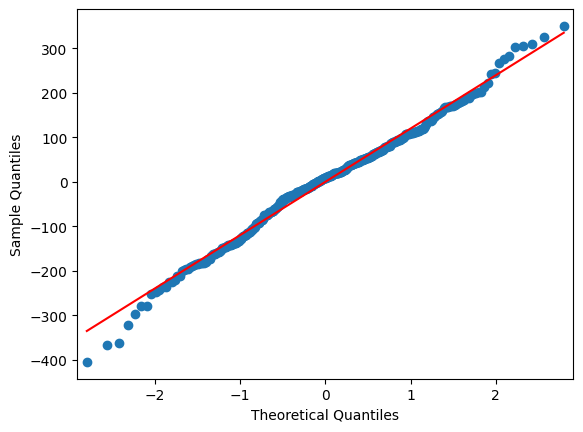

In [57]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [60]:
_df_tmp = df_tmp.loc[df_tmp['ttype']=='fam']
model = smf.mixedlm("tt_corr_rank ~ positive * condition + hse_day", 
                    _df_tmp, groups=_df_tmp["mouse"])

res = model.fit()
res.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Mixed Linear Model Regression Results
===================================================================================
Model:                     MixedLM         Dependent Variable:         tt_corr_rank
No. Observations:          428             Method:                     REML        
No. Groups:                16              Scale:                      17816.2420  
Min. group size:           2               Log-Likelihood:             -2696.2280  
Max. group size:           30              Converged:                  Yes         
Mean group size:           26.8                                                    
-----------------------------------------------------------------------------------
                                     Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------------------------
Intercept                            296.853   76.432  3.884 0.000  147.048 446.657
positive[T.True]                     -21.390   18.877 -1.133 0.257  -58.387  15.607
condition[T.ctrl]                     26.490  101.536  0.261 0.794 -172.518 225.497
hse_day[T.1]                          70.976   17.179  4.132 0.000   37.306 104.646
hse_day[T.2]                          99.212   18.149  5.466 0.000   63.640 134.784
hse_day[T.3]                         122.718   21.295  5.763 0.000   80.980 164.455
hse_day[T.4]                         151.913   27.636  5.497 0.000   97.748 206.078
positive[T.True]:condition[T.ctrl]    79.732   25.863  3.083 0.002   29.042 130.422
Group Var                          38938.193  114.228                              
===================================================================================

"""

Shapiro-Wilk: W=0.976, p=2.08e-06
D'Agostino: χ²=35.762, p=1.72e-08


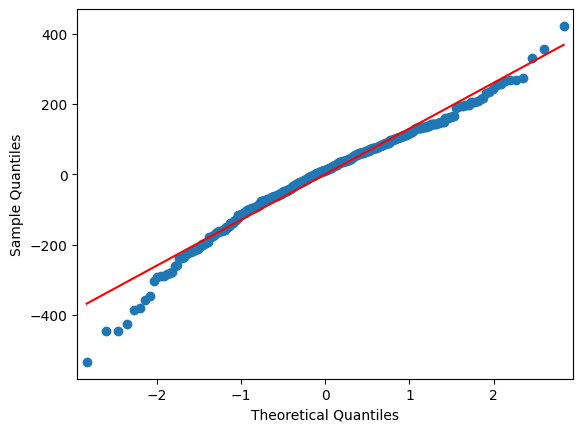

In [61]:
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [ ]:
# permutation test

Text(0.5, 1.0, 'Cre: Nov')

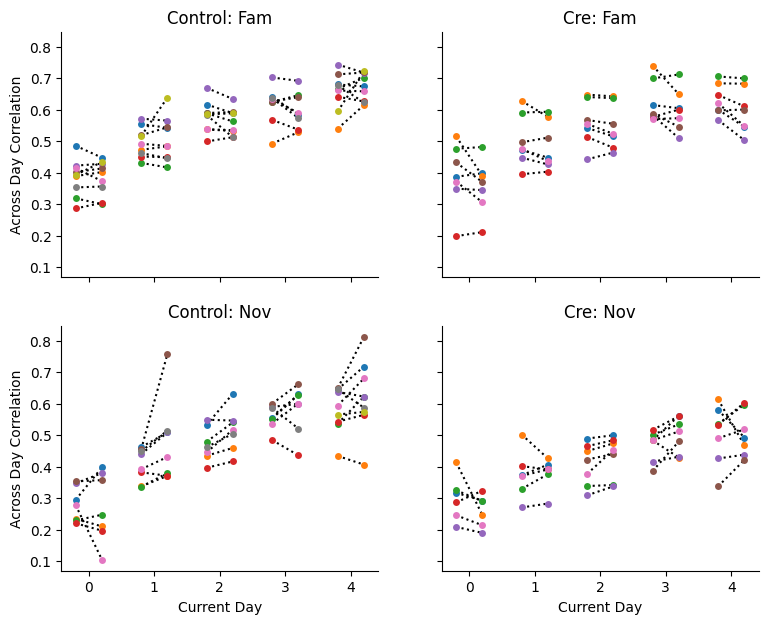

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(9,7), sharex=True, sharey=True)

for k, ttype in enumerate(['fam','nov']):
    old_ind = 0
    for i, mouse in enumerate(ctrl_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='ctrl') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
            
        

        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='across_day_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,0])
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,0].collections[d].get_offsets(), ax[k,0].collections[d+1].get_offsets()):
                ax[k,0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
        


    old_ind = 0
    for i, mouse in enumerate(ko_mice):
        _df = df_grouped.loc[(df_grouped['condition']=='cre') & (df_grouped['mouse']==mouse) & (df_grouped['ttype']==ttype)]
        color = plt.cm.tab10(i)
        _ = sns.stripplot(data= _df,
                            x='hse_day', 
                            y='across_day_corr', 
                            hue='positive',
                            palette=[color, color], 
                            hue_order=[False, True],
                            dodge=True, legend=False,
                            ax=ax[k,1])
        
        new_ind = old_ind + _df['hse_day'].unique().shape[0]*2
        for d in range(old_ind,new_ind,2):
            for (x0, y0), (x1, y1) in zip(ax[k,1].collections[d].get_offsets(), ax[k,1].collections[d+1].get_offsets()):
                ax[k,1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)
        old_ind = new_ind
    
for a in ax.flatten():
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.set_xlabel('Current Day')
    a.set_ylabel('Across Day Correlation')
ax[0,0].set_title('Control: Fam')
ax[0,1].set_title('Cre: Fam')
ax[1,0].set_title('Control: Nov')
ax[1,1].set_title('Cre: Nov')
